# Part 2
### b. Data Augmentation

Create templates for reviews and follow a sentence generator (learned from AI Ethics workshop) to create synthetic sentences

In [12]:
#AI assisted code 
from collections import Counter
from typing import Callable, Dict, List, Literal, Tuple
import json
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel
from tqdm.auto import tqdm

SEED = 1029384756

# Pydantic models
class Vocabulary(BaseModel):
    name: str          # slot name, e.g. "aspect", "detail"
    words: List[str]


class Action(BaseModel):
    text: str          # verb phrase, e.g. "was absolutely wonderful"
    value: str         # category, e.g. "Travel & Vacation"


class Template(BaseModel):
    text: str          # e.g. "The {aspect} {action}. {detail}."


# Extended model: adds a sentiment tier → star-rating range
class ReviewAction(Action):
    sentiment: Literal["positive", "neutral", "negative"]

    @property
    def star_range(self) -> Tuple[int, int]:
        return {
            "positive": (4, 5),
            "neutral":  (3, 3),
            "negative": (1, 2),
        }[self.sentiment]


## adding sentiment vocabulary 

class SentimentVocabulary(BaseModel):
    """A vocabulary whose words are split by sentiment tier.

    When sampled, the generator picks from the tier that matches the
    review's action sentiment with probability `coherence_weight`,
    from the neutral tier with probability `neutral_weight`, and
    from the opposite tier with probability `contrast_weight`.

    The contrast channel preserves thwarted-expectation reviews
    (e.g. "the room was great… but I would not recommend it") so
    the trained model doesn't learn to look for only pure-positive
    or pure-negative signals.
    """
    name: str
    positive: List[str]
    neutral: List[str]
    negative: List[str]

print("Models loaded.")

Models loaded.


### Review actions

What happened / starts with a verb and categorized into positive, netrual and negative feelings.

In [13]:

travel_actions: List[ReviewAction] = [
    # positive
    ReviewAction(text="was absolutely wonderful",           value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="exceeded all my expectations",      value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="made the whole trip worthwhile",    value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was spotless and well-maintained",  value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="provided outstanding service",      value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was a truly memorable experience",  value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was beautifully organized",         value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="felt like a dream come true",       value="Travel & Vacation", sentiment="positive"),
    # neutral
    ReviewAction(text="was acceptable but unremarkable",   value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="met basic expectations",            value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was decent for the price",          value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was average overall",               value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was nothing special",               value="Travel & Vacation", sentiment="neutral"),
    # negative
    ReviewAction(text="was a complete disappointment",     value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="fell far below expectations",       value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was dirty and poorly maintained",   value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="ruined the entire vacation",        value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was overpriced and underwhelming",  value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was the worst I have ever seen",    value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="left us stranded without help",     value="Travel & Vacation", sentiment="negative"),
]

media_actions: List[ReviewAction] = [
    # positive
    ReviewAction(text="was an engaging and captivating read",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="delivered exceptional storytelling",     value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="offered fresh and insightful content",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="was beautifully written and polished",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="kept me hooked from start to finish",    value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="was a standout piece of journalism",     value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="provided real depth and nuance",         value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="set a new standard for the genre",       value="Media & Publishing", sentiment="positive"),
    # neutral
    ReviewAction(text="was a standard read with no surprises",  value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="covered the basics adequately",          value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="had some interesting parts but dragged", value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="was forgettable but not terrible",       value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="neither impressed nor disappointed me",  value="Media & Publishing", sentiment="neutral"),
    # negative
    ReviewAction(text="was riddled with errors and typos",      value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="felt lazy and poorly researched",        value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was misleading and full of bias",        value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="wasted my time completely",              value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was the worst publication I have read",  value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="had zero editorial quality",             value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was clickbait with no real substance",   value="Media & Publishing", sentiment="negative"),
]

all_actions = travel_actions + media_actions

print(f"Travel actions: {len(travel_actions)}  |  Media actions: {len(media_actions)}")
print(f"Total actions:  {len(all_actions)}")

Travel actions: 20  |  Media actions: 20
Total actions:  40


In [14]:
# now create sentence templates using the actions above

travel_templates = [
    Template(text="The {aspect} {action}. {detail}."),
    Template(text="I visited {location} and the {aspect} {action}."),
    Template(text="During our stay, the {aspect} {action}. {recommendation}."),
    Template(text="We booked {qualifier} and the {aspect} {action}."),
    Template(text="After {duration} at {location}, I can say the {aspect} {action}."),
    Template(text="The {aspect} at {location} {action}. {detail}."),
    Template(text="Overall the {aspect} {action}. {qualifier}."),
    Template(text="For a {trip_type} trip, the {aspect} {action}."),
    Template(text="Compared to other places, the {aspect} here {action}. {recommendation}."),
    Template(text="The {aspect} {action}, which really shaped our {trip_type} experience."),
]

media_templates = [
    Template(text="The {media_type} {action}. {detail}."),
    Template(text="I picked up {media_type} by {creator} and it {action}."),
    Template(text="This {media_type} about {topic} {action}. {recommendation}."),
    Template(text="The latest {media_type} from {publisher} {action}."),
    Template(text="After reading the {media_type} on {topic}, I found it {action}. {detail}."),
    Template(text="As a {reader_type}, I think this {media_type} {action}."),
    Template(text="The {media_type} {action}. {qualifier}."),
    Template(text="For anyone interested in {topic}, this {media_type} {action}."),
    Template(text="The editorial quality of the {media_type} {action}. {recommendation}."),
    Template(text="I subscribed for the {topic} coverage and the {media_type} {action}."),
]

print(f"Travel templates: {len(travel_templates)}")
print(f"Media templates:  {len(media_templates)}")

Travel templates: 10
Media templates:  10


In [15]:
# # OLD VOCABULARY (Sentiment MIXED WITHIN VOCAB)

# travel_vocabularies = [
#     Vocabulary(name="aspect", words=[
#         "hotel room", "flight experience", "customer service",
#         "resort amenities", "tour guide", "breakfast buffet",
#         "pool area", "spa treatment", "airport transfer",
#         "beach access", "room service", "check-in process",
#     ]),
#     Vocabulary(name="location", words=[
#         "a seaside resort in Bali", "a boutique hotel in Paris",
#         "a mountain lodge in the Alps", "an all-inclusive in Cancun",
#         "a city hotel in Tokyo", "a safari camp in Kenya",
#         "a countryside B&B in Tuscany", "a cruise ship in the Caribbean",
#     ]),
#     Vocabulary(name="detail", words=[
#         "I would come back in a heartbeat",
#         "The staff went above and beyond",
#         "It was not worth the money at all",
#         "Everything was exactly as advertised",
#         "The photos online were misleading",
#         "We had no complaints whatsoever",
#         "There were several issues during our stay",
#         "The views alone made it worthwhile",
#     ]),
#     Vocabulary(name="recommendation", words=[
#         "Highly recommend for families",
#         "I would not recommend this to anyone",
#         "Great for couples looking for a getaway",
#         "Skip this one and try somewhere else",
#         "Worth every penny for the experience",
#         "Only book this if you have no other options",
#     ]),
#     Vocabulary(name="qualifier", words=[
#         "a last-minute deal online",
#         "through a premium travel agent",
#         "the most expensive package available",
#         "the cheapest option on the site",
#         "a package deal for our anniversary",
#     ]),
#     Vocabulary(name="duration", words=[
#         "a weekend", "five nights", "two weeks", "a full week", "three days",
#     ]),
#     Vocabulary(name="trip_type", words=[
#         "family", "solo", "romantic", "business", "adventure", "budget",
#     ]),
# ]

# # media
# media_vocabularies = [
#     Vocabulary(name="media_type", words=[
#         "magazine", "newspaper", "online journal", "newsletter",
#         "digital edition", "weekly digest", "special report",
#         "anthology", "quarterly review", "podcast transcript",
#     ]),
#     Vocabulary(name="creator", words=[
#         "a well-known columnist", "an independent journalist",
#         "the editorial board", "a first-time author",
#         "a veteran reporter", "a team of investigators",
#     ]),
#     Vocabulary(name="publisher", words=[
#         "a major publishing house", "an indie press",
#         "a university publisher", "an online-only outlet",
#         "a well-established media group", "a nonprofit newsroom",
#     ]),
#     Vocabulary(name="topic", words=[
#         "technology trends", "climate change", "global economics",
#         "cultural history", "modern politics", "health and wellness",
#         "space exploration", "artificial intelligence",
#     ]),
#     Vocabulary(name="detail", words=[
#         "Every paragraph added something new",
#         "The writing quality was surprisingly poor",
#         "I learned a lot from the featured interviews",
#         "It read like an advertisement rather than journalism",
#         "The research behind the piece was impeccable",
#         "I could not get past the first chapter",
#         "The illustrations and layout were top-notch",
#         "There was nothing in it I had not read before",
#     ]),
#     Vocabulary(name="recommendation", words=[
#         "A must-read for anyone in the field",
#         "Save your money and skip this one",
#         "Perfect for a long flight or commute",
#         "Not worth the subscription price",
#         "I have already recommended it to friends",
#         "Only useful as a doorstop",
#     ]),
#     Vocabulary(name="qualifier", words=[
#         "It fills a gap in the market",
#         "There are better alternatives available",
#         "It is a solid choice for beginners",
#         "Seasoned readers will find it lacking",
#         "The price-to-value ratio is fair",
#     ]),
#     Vocabulary(name="reader_type", words=[
#         "regular subscriber", "casual reader", "first-time buyer",
#         "long-time fan of the genre", "professional in the field",
#     ]),
# ]

# for name, vocabs in [("Travel", travel_vocabularies), ("Media", media_vocabularies)]:
#     total_words = sum(len(v.words) for v in vocabs)
#     print(f"{name}: {len(vocabs)} vocabularies, {total_words} total words")

A concern we have is that at the bottom, some of the sentences generated are contradictory. It can be expected that some people can give a good review even if there's something that they didn't like, so don't want to over correct too much, but nervous that if we give the model contradicting sentences, it'll get confused.

At the same time, I think we can make the vocabulary a little better by sentiment WITHOUT having the model learn to only look for purely positive / negative reviews.


In [16]:
## AI assited code below to fix the sentiment alignment

## TRAVEL
# ── Neutral slots (no sentiment) ───────────────────────────────────
travel_neutral_vocabs = [
    Vocabulary(name="aspect", words=[
        "hotel room", "flight experience", "customer service",
        "resort amenities", "tour guide", "breakfast buffet",
        "pool area", "spa treatment", "airport transfer",
        "beach access", "room service", "check-in process",
    ]),
    Vocabulary(name="location", words=[
        "a seaside resort in Bali", "a boutique hotel in Paris",
        "a mountain lodge in the Alps", "an all-inclusive in Cancun",
        "a city hotel in Tokyo", "a safari camp in Kenya",
        "a countryside B&B in Tuscany", "a cruise ship in the Caribbean",
    ]),
    Vocabulary(name="duration", words=[
        "a weekend", "five nights", "two weeks", "a full week", "three days",
    ]),
    Vocabulary(name="trip_type", words=[
        "family", "solo", "romantic", "business", "adventure", "budget",
    ]),
]

# ── Opinion slots (sentiment-split) ────────────────────────────────
travel_sentiment_vocabs = [
    SentimentVocabulary(
        name="detail",
        positive=[
            "I would come back in a heartbeat",
            "The staff went above and beyond",
            "Everything was exactly as advertised",
            "We had no complaints whatsoever",
            "The views alone made it worthwhile",
            "Every detail was thoughtfully arranged",
        ],
        neutral=[
            "It was about what you would expect for the price",
            "Some things were good and others less so",
            "It did the job but nothing stood out",
            "There were both highs and lows during our stay",
        ],
        negative=[
            "It was not worth the money at all",
            "The photos online were misleading",
            "There were several issues during our stay",
            "We could hear noise all night long",
            "The whole place felt neglected",
            "Management did not seem to care",
        ],
    ),
    SentimentVocabulary(
        name="recommendation",
        positive=[
            "Highly recommend for families",
            "Great for couples looking for a getaway",
            "Worth every penny for the experience",
            "Already planning our next visit",
            "I tell everyone about this place",
        ],
        neutral=[
            "It depends on what you are looking for",
            "Might work for a short stay",
            "There are comparable options in the area",
            "Fine if you manage your expectations",
        ],
        negative=[
            "I would not recommend this to anyone",
            "Skip this one and try somewhere else",
            "Only book this if you have no other options",
            "Save your money and look elsewhere",
            "I wish I had read the bad reviews first",
        ],
    ),
    SentimentVocabulary(
        name="qualifier",
        positive=[
            "a premium package and it was worth it",
            "the top-rated option on the site",
            "through a trusted travel agent",
            "a package deal for our anniversary and it delivered",
        ],
        neutral=[
            "a last-minute deal online",
            "a mid-range option after comparing prices",
            "whatever was available on short notice",
        ],
        negative=[
            "the cheapest option and it showed",
            "the most expensive package but it was not worth it",
            "based on fake positive reviews",
            "what was marketed as luxury but clearly was not",
        ],
    ),
]


# MEDIA

# ── Neutral slots ──────────────────────────────────────────────────
media_neutral_vocabs = [
    Vocabulary(name="media_type", words=[
        "magazine", "newspaper", "online journal", "newsletter",
        "digital edition", "weekly digest", "special report",
        "anthology", "quarterly review", "podcast transcript",
    ]),
    Vocabulary(name="creator", words=[
        "a well-known columnist", "an independent journalist",
        "the editorial board", "a first-time author",
        "a veteran reporter", "a team of investigators",
    ]),
    Vocabulary(name="publisher", words=[
        "a major publishing house", "an indie press",
        "a university publisher", "an online-only outlet",
        "a well-established media group", "a nonprofit newsroom",
    ]),
    Vocabulary(name="topic", words=[
        "technology trends", "climate change", "global economics",
        "cultural history", "modern politics", "health and wellness",
        "space exploration", "artificial intelligence",
    ]),
    Vocabulary(name="reader_type", words=[
        "regular subscriber", "casual reader", "first-time buyer",
        "long-time fan of the genre", "professional in the field",
    ]),
]

# ── Opinion slots (sentiment-split) ────────────────────────────────
media_sentiment_vocabs = [
    SentimentVocabulary(
        name="detail",
        positive=[
            "Every paragraph added something new",
            "I learned a lot from the featured interviews",
            "The research behind the piece was impeccable",
            "The illustrations and layout were top-notch",
            "It changed the way I think about the subject",
            "The depth of analysis was remarkable",
        ],
        neutral=[
            "It covered familiar ground competently",
            "Some sections were stronger than others",
            "The writing was serviceable but not memorable",
            "It had a few interesting points buried in filler",
        ],
        negative=[
            "The writing quality was surprisingly poor",
            "It read like an advertisement rather than journalism",
            "I could not get past the first chapter",
            "There was nothing in it I had not read before",
            "The arguments fell apart under any scrutiny",
            "Fact-checking seemed to be an afterthought",
        ],
    ),
    SentimentVocabulary(
        name="recommendation",
        positive=[
            "A must-read for anyone in the field",
            "Perfect for a long flight or commute",
            "I have already recommended it to friends",
            "One of the best things I have read this year",
            "Worth subscribing just for this",
        ],
        neutral=[
            "Read it if you have nothing else on your list",
            "It depends on your level of interest in the topic",
            "Decent enough to skim on a lazy afternoon",
            "Take it or leave it",
        ],
        negative=[
            "Save your money and skip this one",
            "Not worth the subscription price",
            "Only useful as a doorstop",
            "I cancelled my subscription after this",
            "Avoid unless you enjoy being frustrated",
        ],
    ),
    SentimentVocabulary(
        name="qualifier",
        positive=[
            "It fills a gap in the market brilliantly",
            "It is a standout choice for newcomers and experts alike",
            "The price-to-value ratio is excellent",
        ],
        neutral=[
            "It fills a gap in the market",
            "It is a solid choice for beginners",
            "The price-to-value ratio is fair",
        ],
        negative=[
            "There are much better alternatives available",
            "Seasoned readers will find it painfully lacking",
            "It is overpriced for what you actually get",
        ],
    ),
]

for name, nv, sv in [
    ("Travel", travel_neutral_vocabs, travel_sentiment_vocabs),
    ("Media",  media_neutral_vocabs,  media_sentiment_vocabs),
]:
    n_neutral = sum(len(v.words) for v in nv)
    n_sent = sum(len(v.positive) + len(v.neutral) + len(v.negative) for v in sv)
    print(f"{name}: {len(nv)} neutral vocabs ({n_neutral} words) + "
          f"{len(sv)} sentiment vocabs ({n_sent} words)")

Travel: 4 neutral vocabs (31 words) + 3 sentiment vocabs (41 words)
Media: 5 neutral vocabs (35 words) + 3 sentiment vocabs (39 words)


### Generation function

This is building from the code learned in Computational Learning and AI Ethics. 

Also creates the review generation and then from the review generated and the sentiment it has, the function computes a star rating for it.

In [17]:
# pulled from AI Ethics assignment notebook

def capitalize_after_dots(text: str) -> str:
    """Capitalizes the first lowercase letter at the start and after each period."""
    if not text:
        return text
    return re.sub(
        r'((?:^|\.)(?:\s*))([a-z])',
        lambda m: m.group(1) + m.group(2).upper(),
        text,
    )


fixes: List[Callable[[str], str]] = [capitalize_after_dots]

#AI assisted below

# ── Sentiment-tier opposites ───────────────────────────────────────
_OPPOSITE = {"positive": "negative", "negative": "positive", "neutral": "neutral"}


def _pick_from_sentiment_vocab(
    sv: SentimentVocabulary,
    action_sentiment: str,
    rng: random.Random,
    coherence_weight: float = 0.70,
    neutral_weight: float = 0.20,
    contrast_weight: float = 0.10,
) -> str:
    """Sample a word from a SentimentVocabulary, biased toward coherence."""
    tiers = {
        action_sentiment:              (coherence_weight, getattr(sv, action_sentiment)),
        "neutral":                     (neutral_weight,   sv.neutral),
        _OPPOSITE[action_sentiment]:   (contrast_weight,  getattr(sv, _OPPOSITE[action_sentiment])),
    }
    # Deduplicate if action_sentiment == "neutral" (neutral appears twice)
    tier_list = list(tiers.values())
    weights = [t[0] for t in tier_list]
    pools   = [t[1] for t in tier_list]

    # Pick tier, then pick word
    chosen_pool = rng.choices(pools, weights=weights, k=1)[0]
    return rng.choice(chosen_pool)


def generate_reviews(
    templates: List[Template],
    actions: List[ReviewAction],
    neutral_vocabs: List[Vocabulary],
    sentiment_vocabs: List[SentimentVocabulary],
    n_reviews: int = 500,
    rating_weights: Dict[int, float] | None = None,
    coherence_weight: float = 0.70,
    neutral_weight: float = 0.20,
    contrast_weight: float = 0.10,
    seed: int = 42,
) -> List[Dict]:
    """
    Generate synthetic reviews with star ratings and sentiment-coherent slots.

    Adapted from `generate_sentences` in class_notebook.ipynb (cell 15).

    Parameters
    ----------
    templates        : Review sentence patterns with {slot} placeholders.
    actions          : Opinion phrases tagged with category + sentiment.
    neutral_vocabs   : Plain Vocabulary objects for factual slots.
    sentiment_vocabs : SentimentVocabulary objects for opinion slots.
    n_reviews        : Total number of reviews to generate.
    rating_weights   : Desired relative frequency of each star {1: w, …, 5: w}.
    coherence_weight : P(same sentiment) for opinion slots.
    neutral_weight   : P(neutral tier) for opinion slots.
    contrast_weight  : P(opposite sentiment) — thwarted expectations.
    seed             : Reproducibility seed.
    """
    rng = random.Random(seed)

    if rating_weights is None:
        rating_weights = {1: 0.10, 2: 0.10, 3: 0.20, 4: 0.30, 5: 0.30}

    # Index lookups
    neutral_dict = {v.name: v.words for v in neutral_vocabs}
    sentiment_dict = {sv.name: sv for sv in sentiment_vocabs}

    actions_by_sentiment: Dict[str, List[ReviewAction]] = {}
    for a in actions:
        actions_by_sentiment.setdefault(a.sentiment, []).append(a)

    star_to_sentiment = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}

    # Pre-compute per-star counts
    stars = list(rating_weights.keys())
    weights = [rating_weights[s] for s in stars]
    total_w = sum(weights)
    counts = {s: int(round(n_reviews * w / total_w)) for s, w in zip(stars, weights)}
    diff = n_reviews - sum(counts.values())
    counts[max(counts, key=lambda s: rating_weights[s])] += diff

    reviews = []

    for star, count in tqdm(counts.items(), desc="Stars", leave=False):
        sentiment = star_to_sentiment[star]
        tier_actions = actions_by_sentiment.get(sentiment, [])
        if not tier_actions:
            continue

        for i in range(count):
            action = rng.choice(tier_actions)
            template = rng.choice(templates)

            chosen_slots = {"action": action.text, "sample_index": i}
            template_slots = set(re.findall(r"{([a-zA-Z_][a-zA-Z0-9_]*)}", template.text))

            for slot_name in template_slots:
                if slot_name in chosen_slots:
                    continue
                # Sentiment-aware slot?
                if slot_name in sentiment_dict:
                    chosen_slots[slot_name] = _pick_from_sentiment_vocab(
                        sentiment_dict[slot_name], sentiment, rng,
                        coherence_weight, neutral_weight, contrast_weight,
                    )
                elif slot_name in neutral_dict:
                    chosen_slots[slot_name] = rng.choice(neutral_dict[slot_name])

            filled_text = template.text.format(**chosen_slots)
            for fix in fixes:
                filled_text = fix(filled_text)

            reviews.append({
                "text": filled_text,
                "category": action.value,
                "star_rating": star,
                "sentiment": sentiment,
                "template": template.text,
                "action": action.text,
                "slots": chosen_slots,
            })

    rng.shuffle(reviews)
    return reviews


print("generate_reviews() defined — with sentiment-coherent slot sampling.")


generate_reviews() defined — with sentiment-coherent slot sampling.


### Create the sentences


In [18]:
RATING_WEIGHTS = {1: 0.20, 2: 0.20, 3: 0.20, 4: 0.20, 5: 0.20} # even distribution
N_PER_CATEGORY = 1000

travel_reviews = generate_reviews(
    templates=travel_templates,
    actions=travel_actions,
    neutral_vocabs=travel_neutral_vocabs,
    sentiment_vocabs=travel_sentiment_vocabs,
    n_reviews=N_PER_CATEGORY,
    rating_weights=RATING_WEIGHTS,
    seed=SEED,
)

media_reviews = generate_reviews(
    templates=media_templates,
    actions=media_actions,
    neutral_vocabs=media_neutral_vocabs,
    sentiment_vocabs=media_sentiment_vocabs,
    n_reviews=N_PER_CATEGORY,
    rating_weights=RATING_WEIGHTS,
    seed=SEED,
)

all_reviews = travel_reviews + media_reviews
random.Random(SEED).shuffle(all_reviews)

df_augmented = pd.DataFrame(all_reviews)
df_augmented.drop(columns=["slots"], inplace=True)

print(f"Total generated reviews: {len(df_augmented)}")
print(f"\nCategory distribution:\n{df_augmented['category'].value_counts()}")
print(f"\nStar-rating distribution:\n{df_augmented['star_rating'].value_counts().sort_index()}")
print(f"\nSample reviews:")
df_augmented.head(5)

Stars:   0%|          | 0/5 [00:00<?, ?it/s]

Stars:   0%|          | 0/5 [00:00<?, ?it/s]

Total generated reviews: 2000

Category distribution:
category
Media & Publishing    1000
Travel & Vacation     1000
Name: count, dtype: int64

Star-rating distribution:
star_rating
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64

Sample reviews:


,text,category,star_rating,sentiment,template,action
0,The latest magazine from a nonprofit newsroom ...,Media & Publishing,3,neutral,The latest {media_type} from {publisher} {acti...,was forgettable but not terrible
1,"For a adventure trip, the room service was bea...",Travel & Vacation,4,positive,"For a {trip_type} trip, the {aspect} {action}.",was beautifully organized
2,The digital edition was forgettable but not te...,Media & Publishing,3,neutral,The {media_type} {action}. {detail}.,was forgettable but not terrible
3,I picked up newspaper by a veteran reporter an...,Media & Publishing,3,neutral,I picked up {media_type} by {creator} and it {...,had some interesting parts but dragged
4,After a full week at an all-inclusive in Cancu...,Travel & Vacation,1,negative,"After {duration} at {location}, I can say the ...",was overpriced and underwhelming


## check visually that things make sense

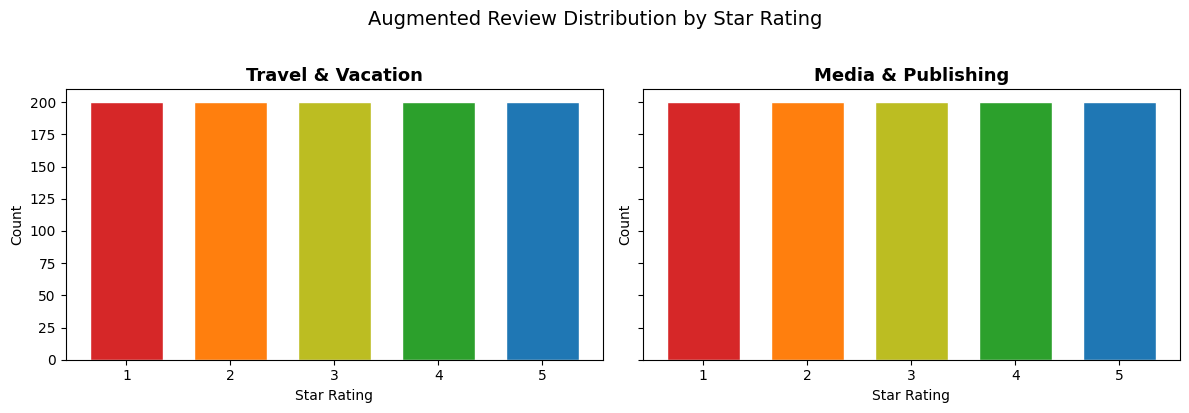

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, cat in zip(axes, ["Travel & Vacation", "Media & Publishing"]):
    subset = df_augmented[df_augmented["category"] == cat]
    counts = subset["star_rating"].value_counts().sort_index()
    colors = ["#D62728", "#FF7F0E", "#BCBD22", "#2CA02C", "#1F77B4"]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.7)
    ax.set_title(cat, fontsize=13, fontweight="bold")
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])

fig.suptitle("Augmented Review Distribution by Star Rating", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
export_path = "augmented_reviews.csv"
df_augmented.to_csv(export_path, index=False, sep="\t")
print(f"Saved {len(df_augmented)} reviews to {export_path}")
print(f"Columns: {list(df_augmented.columns)}")

Saved 2000 reviews to augmented_reviews.csv
Columns: ['text', 'category', 'star_rating', 'sentiment', 'template', 'action']


# Evaluate on BERT Model